# Tugas 10 - Klasifikasi Mahasiswa dengan Perceptron

**Panji Kurnia Akbar (2024081024) - SISTEM INFORMASI**  
**Mata Kuliah:** Introduction to AI.

---
### Tugas 1: Tuliskan Rumus Perceptron
Rumus dari Perceptron adalah perhitungan nilai linear (jumlah bobot dan fitur ditambah dengan bias) yang dilanjutkan dengan fungsi aktivasi (step function). 
- **Persamaan Linear:**  $$z = w_1x_1 + w_2x_2 + b$$
- **Fungsi Aktivasi Output:**  
  $$y = 1 \text{ jika } z \geq 0$$
  $$y = 0 \text{ jika } z < 0$$

### Tugas 3: Apa Fungsi Perceptron dalam Machine Learning?
Perceptron adalah salah satu bentuk *Artificial Neural Network* (ANN) paling sederhana yang berfungsi sebagai pengklasifikasi biner (*binary classifier*). Fungsi utamanya adalah untuk memisahkan data menjadi dua kategori/kelas yang berbeda (linear probem) dengan membangun *decision boundary* (garis pembatas linear) melintasi dimensi dari fitur masukan berdasarkan bobot ($w$) dan bias ($b$).

### 1. Import Library
Pada tahapan ini kita mengimpor beberapa *library* yang akan digunakan pada eksperimen kali ini:
- `pandas`: Digunakan untuk menghasilkan dan menampilkan tabel data (*dataframe*).
- `matplotlib.pyplot` dan `seaborn`: Digunakan nantinya untuk membuat visualisasi dan *scatterplot* data yang estetik/bagus.
- `numpy`: Digunakan untuk mempermudah perhitungan matematik/array.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style untuk visualisasi grafik yang lebih baik nantinya
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

### 2. Mempersiapkan Data Mahasiswa
Pada tahapan ini kita memasukkan *dataset* awal yang memuat parameter `IPK`, `SKS`, dan `Status` ke dalam `pandas.DataFrame` untuk melihatnya dalam bentuk tabel rapi.

In [2]:
# Deklarasi dataset
data = {
    'IPK': [3.5, 2.8, 3.2],
    'SKS': [22, 18, 20],
    'Status': [1, 0, 1]
}

# Membuat DataFrame menggunakan Pandas
df = pd.DataFrame(data)

# Merubah kolom status menjadi string agar memudahkan penggambaran keterangan chart nanti
df['Keterangan_Status'] = df['Status'].map({1: 'Lulus (1)', 0: 'Tidak Lulus (0)'})

# Menampilkan Tabel Dataset Secara Rapi
display(df[['IPK', 'SKS', 'Status']])

,IPK,SKS,Status
0,3.5,22,1
1,2.8,18,0
2,3.2,20,1


### 3. Perhitungan Nilai Output Perceptron untuk Data Pertama
Pada *Tugas 2*, kita diminta menghitung nilai *z* dan *output* perceptron untuk data pertama berdasarkan bobot yang diberikan yaitu:
- $w_1 = 1$
- $w_2 = 1$
- $b = -20$

Data pertama adalah:
- **IPK ($x_1$)** : `3.5`
- **SKS ($x_2$)**: `22`

Berikut adalah kode penerapan rumus dan kalkulasi matematisnya, sekaligus visualisasi *Decision Boundary* dari Perceptron tersebut terhadap data kita.

In [7]:
from IPython.display import display, HTML

# Parameter bobot Perceptron sesuai Tugas 2
w1 = 1
w2 = 1
b = -20

# Data Pertama
x1 = df.iloc[0]['IPK']
x2 = df.iloc[0]['SKS']
actual_status = df.iloc[0]['Status']

# Menghitung Z
z = (w1 * x1) + (w2 * x2) + b

# Fungsi aktivasi (Hitung y)
y = 1 if z >= 0 else 0

# Membuat DataFrame untuk menampilkan hasil perhitungan dalam bentuk tabel rapi
hasil_tabel = pd.DataFrame({
    "Komponen Perhitungan": [
        "Input 1: IPK (x1)", 
        "Input 2: SKS (x2)", 
        "Bobot 1 (w1)", 
        "Bobot 2 (w2)", 
        "Bias (b)", 
        "Perhitungan Skor Linear (z)", 
        "Hasil Klasifikasi / Prediksi (y)"
    ],
    "Nilai / Formula kalkulasi": [
        x1, 
        x2, 
        w1, 
        w2, 
        b, 
        f"({w1} * {x1}) + ({w2} * {x2}) + ({b}) = {z}", 
        f"{y}  —  (karena z {'≥' if z >= 0 else '<'} 0)"
    ]
})

print("📝 Rincian Perhitungan Perceptron Data Pertama:")
# Menampilkan tabel dengan gaya default Pandas DataFrame (seperti Cell 5) namun tanpa nomor index
display(HTML(hasil_tabel.to_html(index=False)))

📝 Rincian Perhitungan Perceptron Data Pertama:


Komponen Perhitungan,Nilai / Formula kalkulasi
Input 1: IPK (x1),3.5
Input 2: SKS (x2),22
Bobot 1 (w1),1
Bobot 2 (w2),1
Bias (b),-20
Perhitungan Skor Linear (z),(1 * 3.5) + (1 * 22) + (-20) = 5.5
Hasil Klasifikasi / Prediksi (y),1 — (karena z ≥ 0)


### 4. Visualisasi Perceptron dan Decision Boundary
Pada tahap ini, kita memvisualisasikan persebaran data mahasiswa beserta *Decision Boundary* dari model Perceptron dengan bobot dan bias yang telah ditentukan. Kita juga memberikan *highlight* khusus untuk melihat posisi "Data Pertama" yang nilai Perceptron-nya baru saja kita hitung (apakah posisinya di atas/masuk ke dalam label target yang sesuai).

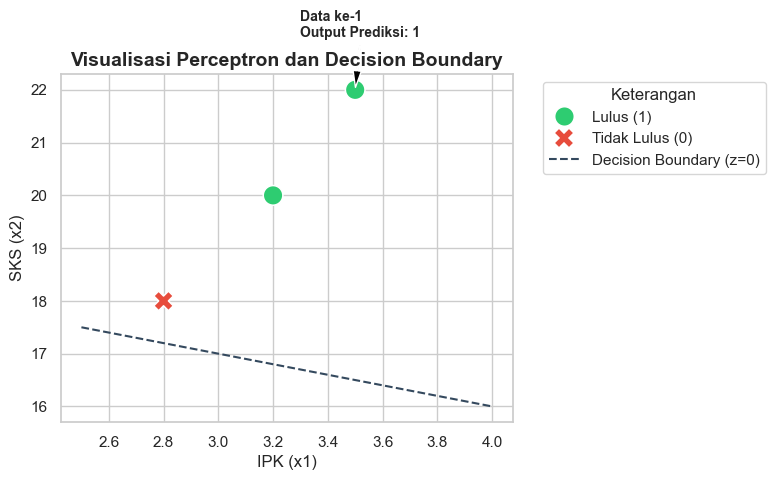

In [4]:
# Menampilkan Decision Boundary Graph
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='IPK', 
    y='SKS', 
    hue='Keterangan_Status', 
    style='Keterangan_Status',
    s=200, 
    palette=['#2ecc71', '#e74c3c'] 
)

# Line Equation untuk Decision Boundary: w1*x1 + w2*x2 + b = 0 => x2 = (-w1*x1 - b)/w2
# Mendapatkan range nilai X untuk menggambarkan garis
x_vals = np.linspace(2.5, 4.0, 100)
y_vals = (-w1 * x_vals - b) / w2

plt.plot(x_vals, y_vals, '--', color='#34495e', label='Decision Boundary (z=0)')

# Highlight / Anotasi data pertama
plt.annotate(
    f"Data ke-1\nOutput Prediksi: {y}", 
    xy=(x1, x2), 
    xytext=(x1 - 0.2, x2 + 1),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    fontweight='bold'
)

plt.title("Visualisasi Perceptron dan Decision Boundary", fontsize=14, fontweight='bold')
plt.xlabel("IPK (x1)", fontsize=12)
plt.ylabel("SKS (x2)", fontsize=12)
plt.legend(title='Keterangan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()